In [1]:
%pip install shap

     ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
     - ----------------------------------- 20.5/547.0 kB 640.0 kB/s eta 0:00:01
     ---- -------------------------------- 61.4/547.0 kB 544.7 kB/s eta 0:00:01
     ---- -------------------------------- 61.4/547.0 kB 544.7 kB/s eta 0:00:01
     ---------- ------------------------- 153.6/547.0 kB 833.5 kB/s eta 0:00:01
     ---------- ------------------------- 153.6/547.0 kB 833.5 kB/s eta 0:00:01
     ------------- ---------------------- 204.8/547.0 kB 827.9 kB/s eta 0:00:01
     ------------------------ ------------- 348.2/547.0 kB 1.1 MB/s eta 0:00:01
     ------------------------ ------------- 348.2/547.0 kB 1.1 MB/s eta 0:00:01
     ----------------------------- -------- 430.1/547.0 kB 1.1 MB/s eta 0:00:01
     -------------------------------------  542.7/547.0 kB 1.2 MB/s eta 0:00:01
     -------------------------------------- 547.0/547.0 kB 1.1 MB/s eta 0:00:00
     ---------------------------------------- 0

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 23.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import shap

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

print("TensorFlow version:", tf.__version__)
print("SHAP version:", shap.__version__)

c:\Users\yehan\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


TensorFlow version: 2.21.0
SHAP version: 0.49.1


In [3]:
MODEL_PATH = r"E:\DermaAI_DiagnosticTool\models\mobilenetv2_finetuned_final_model.keras"
SPLIT_DIR = r"E:\DermaAI_DiagnosticTool\outputs\splits"
OUTPUT_DIR = r"E:\DermaAI_DiagnosticTool\outputs"
SHAP_DIR = os.path.join(OUTPUT_DIR, "shap_outputs")

os.makedirs(SHAP_DIR, exist_ok=True)

model = load_model(MODEL_PATH)

train_df = pd.read_csv(os.path.join(SPLIT_DIR, "train_metadata.csv"))
test_df = pd.read_csv(os.path.join(SPLIT_DIR, "test_metadata.csv"))

CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

lesion_type_dict = {
    "akiec": "Actinic keratoses and intraepithelial carcinoma",
    "bcc": "Basal cell carcinoma",
    "bkl": "Benign keratosis like lesions",
    "df": "Dermatofibroma",
    "mel": "Melanoma",
    "nv": "Melanocytic nevi",
    "vasc": "Vascular lesions"
}

print("Model loaded successfully")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("SHAP output folder:", SHAP_DIR)

Model loaded successfully
Train shape: (6985, 10)
Test shape: (1549, 10)
SHAP output folder: E:\DermaAI_DiagnosticTool\outputs\shap_outputs


In [4]:
IMG_SIZE = (224, 224)

def load_image_for_model(image_path):
    img = image.load_img(image_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)
    return img_array

def load_image_batch(image_paths):
    images = []

    for path in image_paths:
        images.append(load_image_for_model(path))

    return np.array(images)

In [5]:
background_df = train_df.sample(4, random_state=42)
explain_df = test_df.sample(1, random_state=12)

background_images = load_image_batch(background_df["image_path"].tolist())
explain_images = load_image_batch(explain_df["image_path"].tolist())

print("Background images shape:", background_images.shape)
print("Explain images shape:", explain_images.shape)

sample_path = explain_df.iloc[0]["image_path"]
true_label = explain_df.iloc[0]["dx"]

predictions = model.predict(explain_images)
predicted_index = np.argmax(predictions[0])
predicted_label = CLASS_NAMES[predicted_index]
confidence = predictions[0][predicted_index]

print("True label:", true_label, "-", lesion_type_dict[true_label])
print("Predicted label:", predicted_label, "-", lesion_type_dict[predicted_label])
print("Confidence:", round(float(confidence) * 100, 2), "%")

Background images shape: (4, 224, 224, 3)
Explain images shape: (1, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
True label: nv - Melanocytic nevi
Predicted label: mel - Melanoma
Confidence: 39.04 %


In [6]:
explainer = shap.GradientExplainer(
    model,
    background_images
)

shap_values = explainer.shap_values(explain_images)

print("SHAP values generated successfully")
print("Type:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP outputs:", len(shap_values))
    print("Shape of selected class SHAP values:", np.array(shap_values[predicted_index]).shape)
else:
    print("SHAP values shape:", np.array(shap_values).shape)

c:\Users\yehan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(1, 224, 224, 3))']
  warnings.warn(msg)
c:\Users\yehan\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(50, 224, 224, 3))']
  warnings.warn(msg)


SHAP values generated successfully
Type: <class 'numpy.ndarray'>
SHAP values shape: (1, 224, 224, 3, 7)


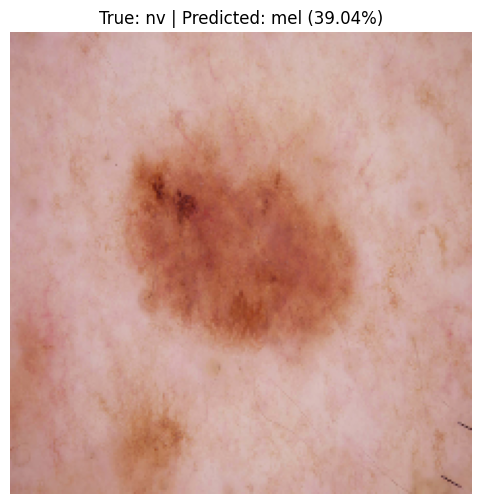

In [7]:
def undo_mobilenet_preprocess(img_array):
    img = (img_array + 1.0) * 127.5
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

display_image = undo_mobilenet_preprocess(explain_images[0])

plt.figure(figsize=(6, 6))
plt.imshow(display_image)
plt.title(
    f"True: {true_label} | Predicted: {predicted_label} "
    f"({round(float(confidence) * 100, 2)}%)"
)
plt.axis("off")
plt.show()

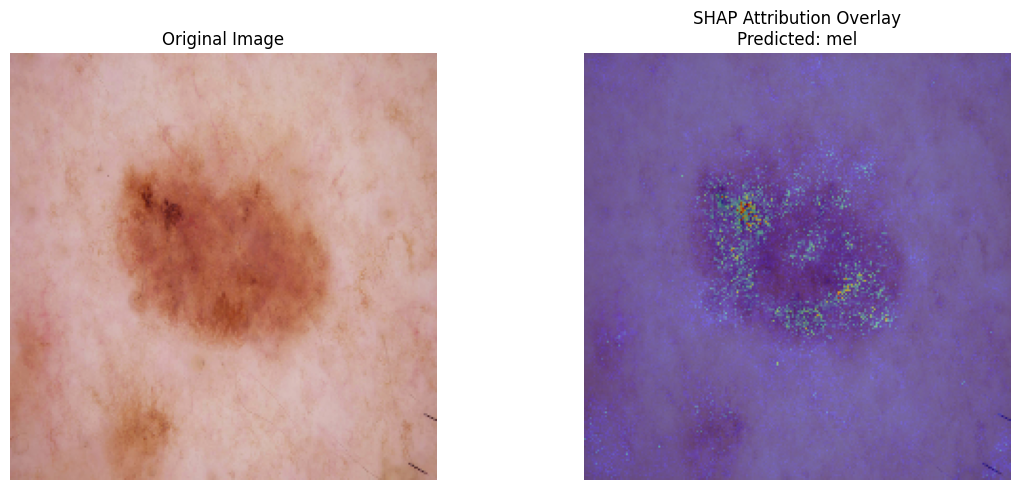

SHAP overlay saved to: E:\DermaAI_DiagnosticTool\outputs\shap_outputs\shap_overlay_true_nv_pred_mel.png


In [8]:
shap_values_array = np.array(shap_values)

# SHAP shape is: (samples, height, width, channels, classes)
selected_shap_values = shap_values_array[0, :, :, :, predicted_index]

# Convert RGB channel attributions into one heatmap
shap_map = np.mean(np.abs(selected_shap_values), axis=-1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(display_image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(display_image)
plt.imshow(shap_map, cmap="jet", alpha=0.45)
plt.title(f"SHAP Attribution Overlay\nPredicted: {predicted_label}")
plt.axis("off")

plt.tight_layout()

shap_output_path = os.path.join(
    SHAP_DIR,
    f"shap_overlay_true_{true_label}_pred_{predicted_label}.png"
)

plt.savefig(shap_output_path, dpi=300, bbox_inches="tight")
plt.show()

print("SHAP overlay saved to:", shap_output_path)

In [9]:
probability_table = pd.DataFrame({
    "class_code": CLASS_NAMES,
    "class_name": [lesion_type_dict[class_code] for class_code in CLASS_NAMES],
    "probability": predictions[0]
})

probability_table["probability_percent"] = (
    probability_table["probability"] * 100
).round(2)

probability_table = probability_table.sort_values(
    by="probability",
    ascending=False
)

display(probability_table)

probability_path = os.path.join(
    SHAP_DIR,
    "shap_example_probability_table.csv"
)

probability_table.to_csv(probability_path, index=False)

print("Probability table saved to:", probability_path)

,class_code,class_name,probability,probability_percent
4,mel,Melanoma,0.390409,39.040001
5,nv,Melanocytic nevi,0.251605,25.160000
2,bkl,Benign keratosis like lesions,0.217764,21.780001
3,df,Dermatofibroma,0.044442,4.440000
0,akiec,Actinic keratoses and intraepithelial carcinoma,0.044367,4.440000
1,bcc,Basal cell carcinoma,0.034340,3.430000
6,vasc,Vascular lesions,0.017073,1.710000


Probability table saved to: E:\DermaAI_DiagnosticTool\outputs\shap_outputs\shap_example_probability_table.csv


## SHAP Explainability Summary

A limited SHAP based explanation was implemented as a secondary interpretability method for the fine tuned MobileNetV2 model. A small background sample was selected from the training set, and one test image was explained using GradientExplainer.

The SHAP attribution overlay highlights image regions that contributed to the model prediction. This provides a complementary explanation to Grad CAM by showing pixel level attribution patterns rather than only convolutional activation regions.

In the tested example, the true class was melanocytic nevi, while the model predicted melanoma with 39.04 percent confidence. The probability distribution also showed notable confidence for melanocytic nevi and benign keratosis like lesions, indicating uncertainty between visually similar lesion categories. This supports the need to present predictions with confidence scores and explanation outputs rather than treating the model result as a final diagnosis.

Due to computational limitations, SHAP was applied to a small sample rather than the full test set. This is suitable for this project because SHAP is used as supporting explainability evidence, while Grad CAM remains the primary visual explanation method for the final diagnostic support workflow.